In [1]:
import sys
from pathlib import Path
p = Path.cwd().resolve()
while p != p.parent and not (p / "src").exists():
    p = p.parent
if str(p) not in sys.path:
    sys.path.insert(0, str(p))
    
# !{sys.executable} -m pip install umap-learn

from src.config import Settings, load_settings
from src.preprocessing import preprocess_data, preprocess_report, load_data, review_aggregation, merge_data, scale_features, validate_merge
from src.visualizations import plot_faceted_comparisons, generate_leaderboard, plot_recipe_manifold, find_similar_recipes

s = load_settings()

In [2]:
from src.visualizations import generate_hp_leaderboard

generate_hp_leaderboard(s.results_dir)


=== Hyperparameter Grid Search Leaderboard ===
| Run Date      | Architecture   |     LR |   Batch |   Decay | Ablation     | Loss   |   RMSE |    MSE |    MAE |   Epochs |
|:--------------|:---------------|-------:|--------:|--------:|:-------------|:-------|-------:|-------:|-------:|---------:|
| Mar 12, 23:13 | deep           | 0.0001 |     256 |  0      | all_features | huber  | 0.2967 | 0.088  | 0.2208 |      105 |
| Mar 13, 00:45 | deep           | 0.0005 |     512 |  0      | all_features | huber  | 0.2969 | 0.0881 | 0.2195 |       77 |
| Mar 13, 00:13 | deep           | 0.0005 |     512 |  0.0001 | all_features | huber  | 0.297  | 0.0882 | 0.2192 |       66 |
| Mar 12, 20:10 | deep           | 0.0001 |     128 |  1e-05  | all_features | huber  | 0.2973 | 0.0884 | 0.2202 |       80 |
| Mar 13, 00:01 | deep           | 0.001  |     512 |  0      | all_features | huber  | 0.2979 | 0.0887 | 0.2206 |       52 |
| Mar 12, 23:40 | deep           | 0.001  |     512 |  0.0001 | all_fe

,Run Date,Architecture,LR,Batch,Decay,Ablation,Loss,RMSE,MSE,MAE,Epochs
0,"Mar 12, 23:13",deep,0.0001,256,0.0,all_features,huber,0.2967,0.0880,0.2208,105
1,"Mar 13, 00:45",deep,0.0005,512,0.0,all_features,huber,0.2969,0.0881,0.2195,77
2,"Mar 13, 00:13",deep,0.0005,512,0.0001,all_features,huber,0.2970,0.0882,0.2192,66
3,"Mar 12, 20:10",deep,0.0001,128,1e-05,all_features,huber,0.2973,0.0884,0.2202,80
4,"Mar 13, 00:01",deep,0.001,512,0.0,all_features,huber,0.2979,0.0887,0.2206,52
5,"Mar 12, 23:40",deep,0.001,512,0.0001,all_features,huber,0.2982,0.0889,0.2182,49
6,"Mar 12, 21:58",deep,0.0005,256,1e-05,all_features,huber,0.2982,0.0889,0.2200,47
7,"Mar 12, 22:12",deep,0.0005,256,0.0,all_features,huber,0.2983,0.0890,0.2179,46
8,"Mar 12, 19:33",deep,0.0001,128,0.0001,all_features,huber,0.2986,0.0892,0.2221,97
9,"Mar 12, 21:44",deep,0.0005,256,0.0001,all_features,huber,0.2993,0.0896,0.2209,46


In [8]:
generate_leaderboard(s.results_dir)


=== Latest Model Performance Leaderboard ===
| Run Date      | Architecture   | Ablation     | Loss     |   RMSE |    MSE |    MAE |   Epochs |
|:--------------|:---------------|:-------------|:---------|-------:|-------:|-------:|---------:|
| Mar 12, 23:13 | deep           | all_features | huber    | 0.2967 | 0.088  | 0.2208 |      105 |
| Mar 13, 00:45 | deep           | all_features | huber    | 0.2969 | 0.0881 | 0.2195 |       77 |
| Mar 13, 00:13 | deep           | all_features | huber    | 0.297  | 0.0882 | 0.2192 |       66 |
| Mar 12, 20:10 | deep           | all_features | huber    | 0.2973 | 0.0884 | 0.2202 |       80 |
| Mar 13, 10:24 | shallow        | all_features | log_cash | 0.2973 | 0.0884 | 0.2177 |       92 |
| Mar 12, 14:52 | deep           | all_features | mse      | 0.2974 | 0.0885 | 0.219  |       46 |
| Mar 13, 00:01 | deep           | all_features | huber    | 0.2979 | 0.0887 | 0.2206 |       52 |
| Mar 13, 12:30 | residual       | all_features | huber    | 0.

,Run Date,Architecture,Ablation,Loss,RMSE,MSE,MAE,Epochs
0,"Mar 12, 23:13",deep,all_features,huber,0.2967,0.0880,0.2208,105
1,"Mar 13, 00:45",deep,all_features,huber,0.2969,0.0881,0.2195,77
2,"Mar 13, 00:13",deep,all_features,huber,0.2970,0.0882,0.2192,66
3,"Mar 12, 20:10",deep,all_features,huber,0.2973,0.0884,0.2202,80
4,"Mar 13, 10:24",shallow,all_features,log_cash,0.2973,0.0884,0.2177,92
...,...,...,...,...,...,...,...,...
76,"Mar 12, 17:51",residual_v3,meta_only,mse,0.3785,0.1432,0.2673,51
77,"Mar 12, 15:11",deep,meta_only,mse,0.3804,0.1447,0.2839,50
78,"Mar 13, 00:27",deep,all_features,huber,0.3969,0.1575,0.2222,72
79,"Mar 12, 16:43",residual_v2,meta_only,huber,0.4125,0.1702,0.2731,45


c:\Users\iauge\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


AttributeError: 'list' object has no attribute 'flatten'

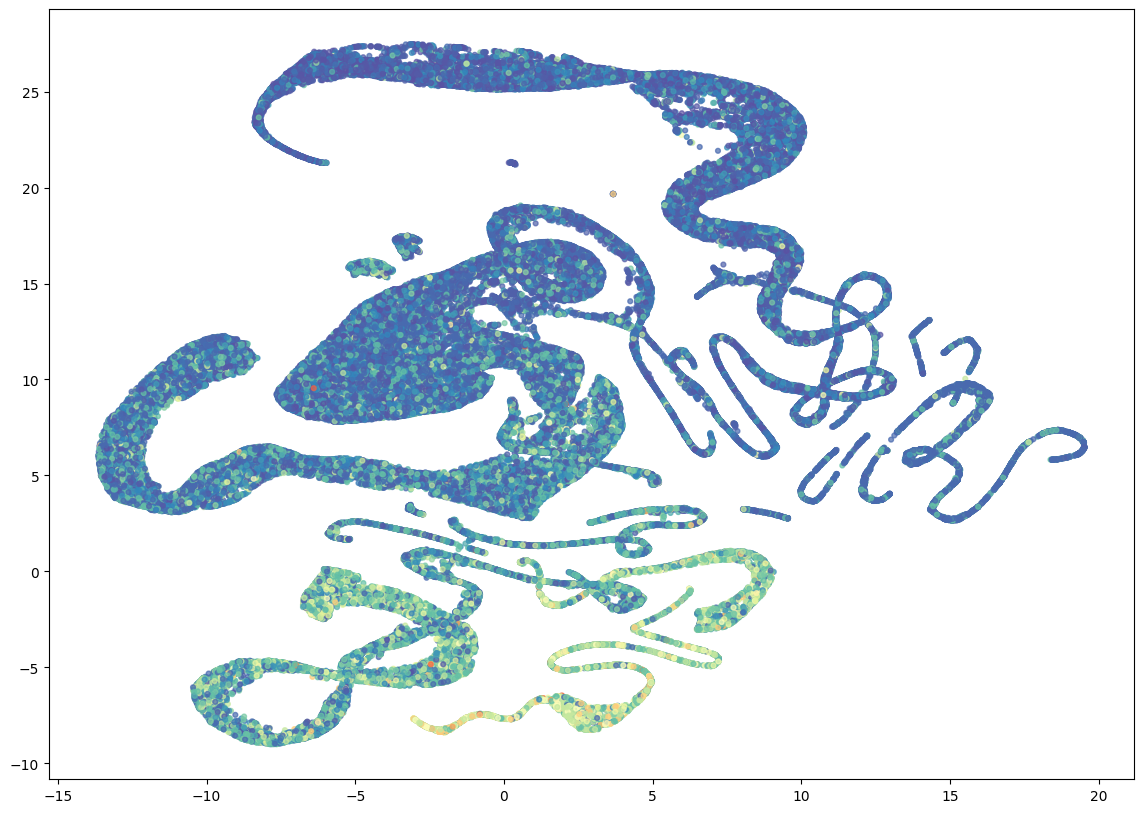

In [2]:
embed_path = str(Path(s.results_dir) / "final_corpus_embeddings.pt")

plot_recipe_manifold(embed_path)

In [ ]:
find_similar_recipes(embed_path, "pear spice cake")

c:\Users\iauge\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


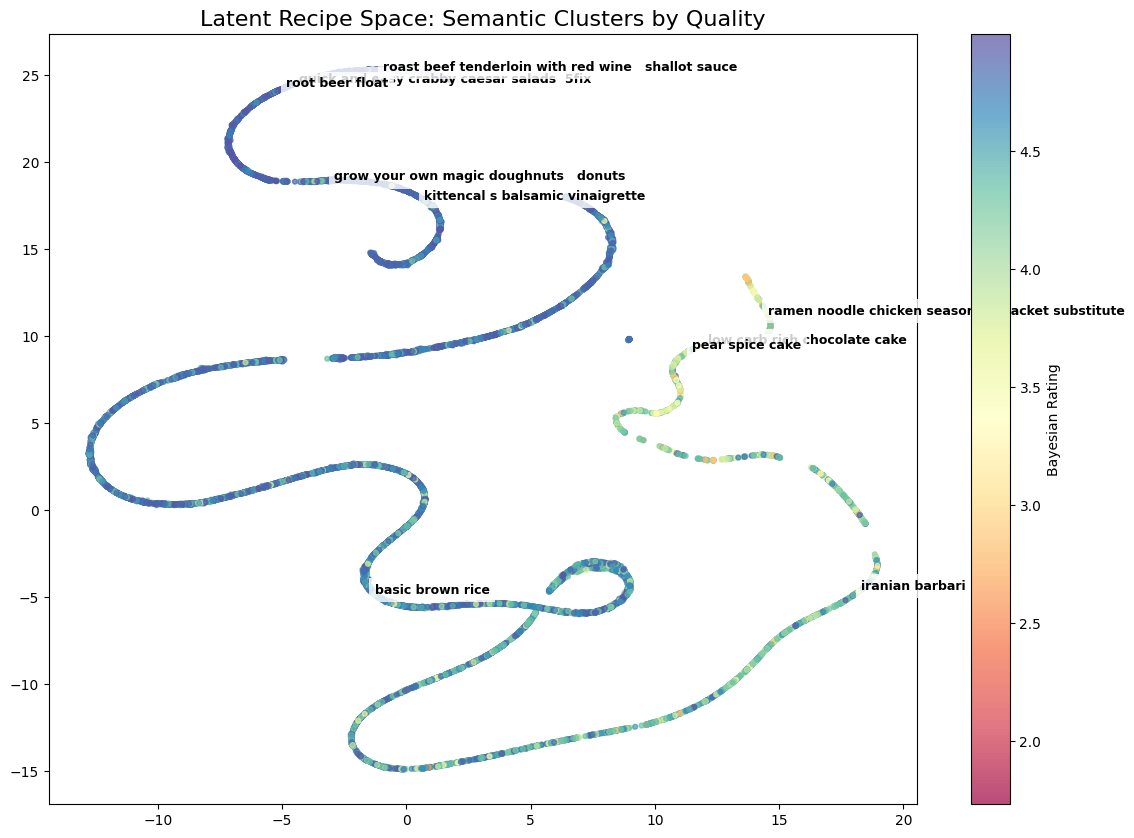

In [7]:
embed_path = str(Path(s.results_dir) / "manifold_bundle_deep_all_features_mse_20260308_113509.pt")
    
plot_recipe_manifold(embed_path)

c:\Users\iauge\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


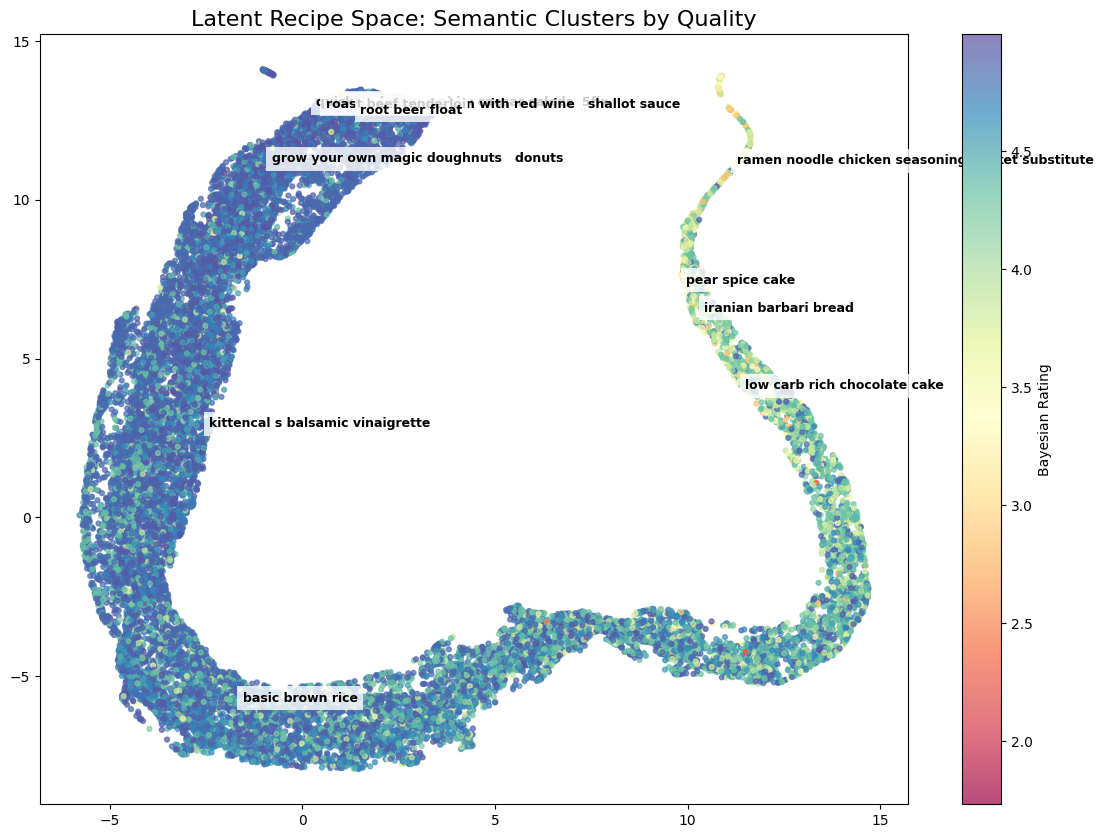

In [8]:
embed_path = str(Path(s.results_dir) / "manifold_bundle_residual_v2_all_features_huber_20260308_143301.pt")

plot_recipe_manifold(embed_path)

In [ ]:
plot_faceted_comparisons(s.results_dir)
